<a href="https://colab.research.google.com/github/Prerna-Karle/Advance-Quantum-Computation/blob/main/P05_Implement_the_Quantum_Fourier_transforms_(QFT)_and_it's_inverse_using_qiskit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit

In [2]:
!pip install qiskit-aer

In [3]:
#Import Required Libraries
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np

In [4]:
#Create QFT Function
def qft(circuit, n):
    for j in range(n):
        circuit.h(j)
        for k in range(j+1, n):
            circuit.cp(np.pi / 2**(k-j), k, j)

    # Swap qubits
    for i in range(n//2):
        circuit.swap(i, n-i-1)

In [5]:
#Create Inverse QFT Function
def inverse_qft(circuit, n):
    # Swap back
    for i in range(n//2):
        circuit.swap(i, n-i-1)

    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)):
            circuit.cp(-np.pi / 2**(k-j), k, j)
        circuit.h(j)

In [6]:
#Create Quantum Circuit
n = 3
qc = QuantumCircuit(n, n)

# Example input state |101>
qc.x(0)
qc.x(2)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [7]:
#Apply QFT
qft(qc, n)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [8]:
#Apply Inverse QFT
inverse_qft(qc, n)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [9]:
#Measurement
qc.measure(range(n), range(n))

In [10]:
!pip install pylatexenc

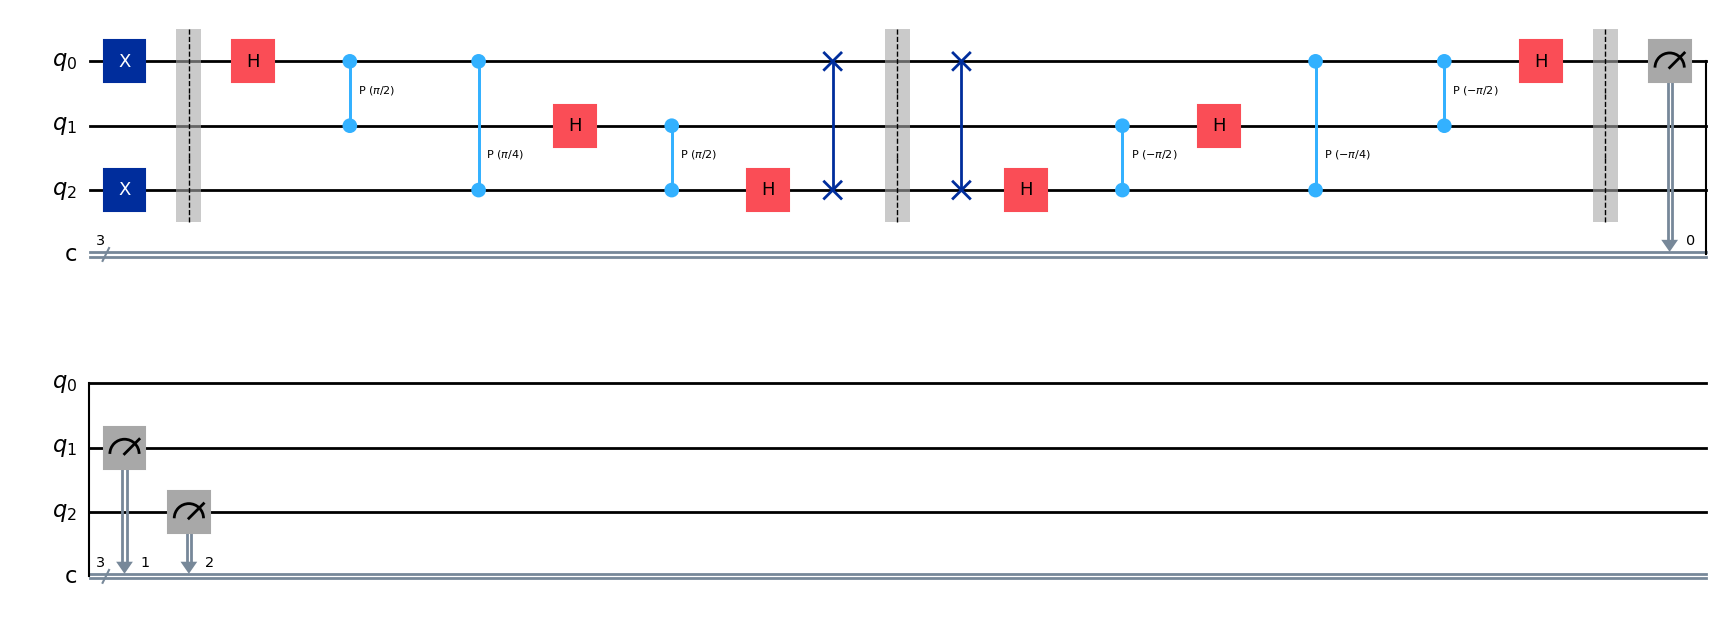

In [11]:
#Draw Circuit
qc.draw('mpl')

In [12]:
#Run Simulation
simulator = AerSimulator()
compiled = transpile(qc, simulator)
result = simulator.run(compiled).result()

counts = result.get_counts()
print(counts)

{'101': 1024}


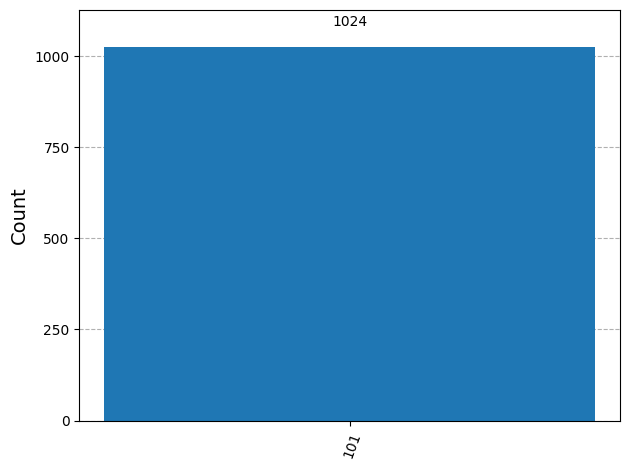

In [13]:
#Plot Result
plot_histogram(counts)